# Actividades Tema 4

---

## Instalación de dependencias

Instalamos las librerías necesarias.

In [14]:
%pip install requests pandas matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


---
## Actividades Obligatorias
---

### EJERCICIO 1

**Monitorización del clúster Hadoop**

Objetivo: Monitorizar un clúster Hadoop mediante tres métodos distintos: interfaces web nativas, herramientas de visualización (Grafana + Prometheus) y línea de comandos.

**Parte 1: Arranque del clúster**

- Descarga y pon en marcha el clúster usando Docker Compose.
- Verifica los siguientes contenedores:
    - namenode
    - datanode
    - resourcemanager
    - nodemanager
    - grafana
    - prometheus

In [15]:
# Descargar y arrancar el clúster Hadoop con Docker Compose
# (Asegúrate de tener docker-compose.yml en el directorio actual)

!docker-compose up -d

namenode is up-to-date
datanode is up-to-date
resourcemanager is up-to-date
nodemanager is up-to-date
prometheus is up-to-date
grafana is up-to-date


In [16]:
# Verificar que todos los contenedores están en ejecución
!docker ps --format "table {{{{.Names}}}}\t{{{{.Status}}}}"

NAMES             STATUS
grafana           Up 11 minutes
prometheus        Up 11 minutes
nodemanager       Up 11 minutes (healthy)
resourcemanager   Up 11 minutes (healthy)
datanode          Up 11 minutes (healthy)
namenode          Up 11 minutes (healthy)


**Parte 2: Monitorización web**

Accede y captura:

- NameNode UI: http://localhost:9870
- DataNode UI: http://localhost:9864
- Resource Manager UI: http://localhost:8088

Describe qué información muestra cada una.

In [17]:
import requests

# Verificar que las interfaces web responden
urls = {
    "NameNode UI": "http://localhost:9870",
    "DataNode UI": "http://localhost:9864",
    "Resource Manager UI": "http://localhost:8088",
}

for name, url in urls.items():
    try:
        r = requests.get(url, timeout=5)
        print(f"✅ {name}: {url} -> Status {r.status_code}")
    except requests.exceptions.ConnectionError:
        print(f"❌ {name}: {url} -> No se pudo conectar")
    except Exception as e:
        print(f"❌ {name}: {url} -> {e}")

✅ NameNode UI: http://localhost:9870 -> Status 200
✅ DataNode UI: http://localhost:9864 -> Status 200
✅ Resource Manager UI: http://localhost:8088 -> Status 200


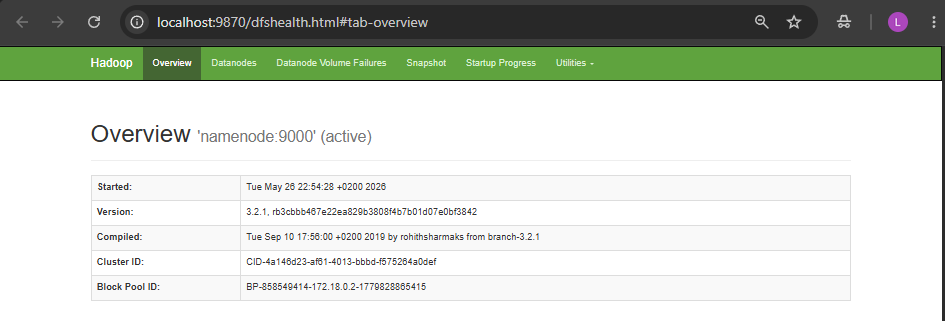
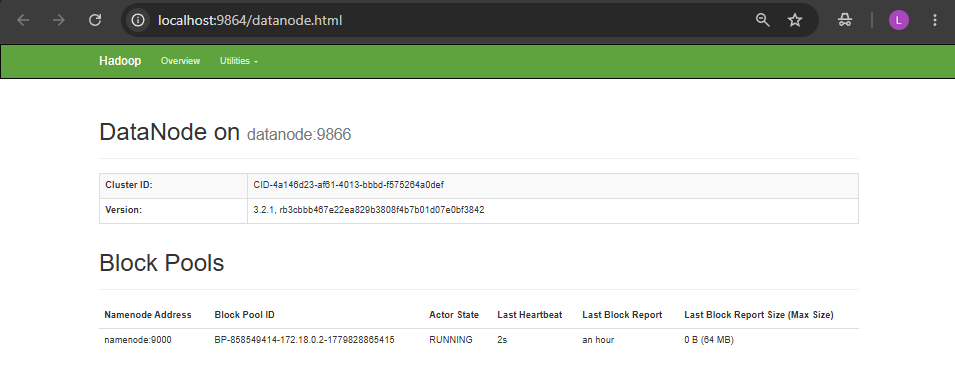
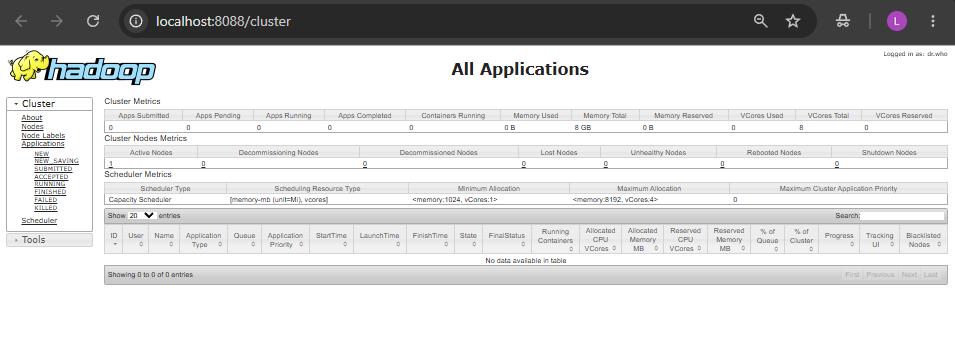

**Descripción de cada interfaz:**

1. **NameNode UI (puerto 9870):** Muestra el estado general del HDFS: espacio total y usado, número de bloques, nodos vivos/muertos, capacidad del clúster, configuración del sistema de archivos.

2. **DataNode UI (puerto 9864):** Proporciona información individual de cada DataNode: bloques almacenados, capacidad usada, estado de salud, últimas operaciones.

3. **Resource Manager UI (puerto 8088):** Muestra el estado de YARN: aplicaciones en ejecución/finalizadas, uso de memoria y CPU por nodo, colas de recursos, scheduling.


**Parte 3: Prometheus y Grafana**

- Prometheus: http://localhost:9090
- Grafana: http://localhost:3000
- Ejecuta una consulta (ej: jmx_exporter_up)
- Crea una visualización
- Configura una alerta

In [18]:
# Verificar que Prometheus y Grafana están accesibles
mon_urls = {
    "Prometheus": "http://localhost:9090",
    "Grafana": "http://localhost:3000",
}

for name, url in mon_urls.items():
    try:
        r = requests.get(url, timeout=5)
        print(f"✅ {name}: {url} -> Status {r.status_code}")
    except Exception:
        print(f"❌ {name}: {url} -> No se pudo conectar")

✅ Prometheus: http://localhost:9090 -> Status 200
✅ Grafana: http://localhost:3000 -> Status 200


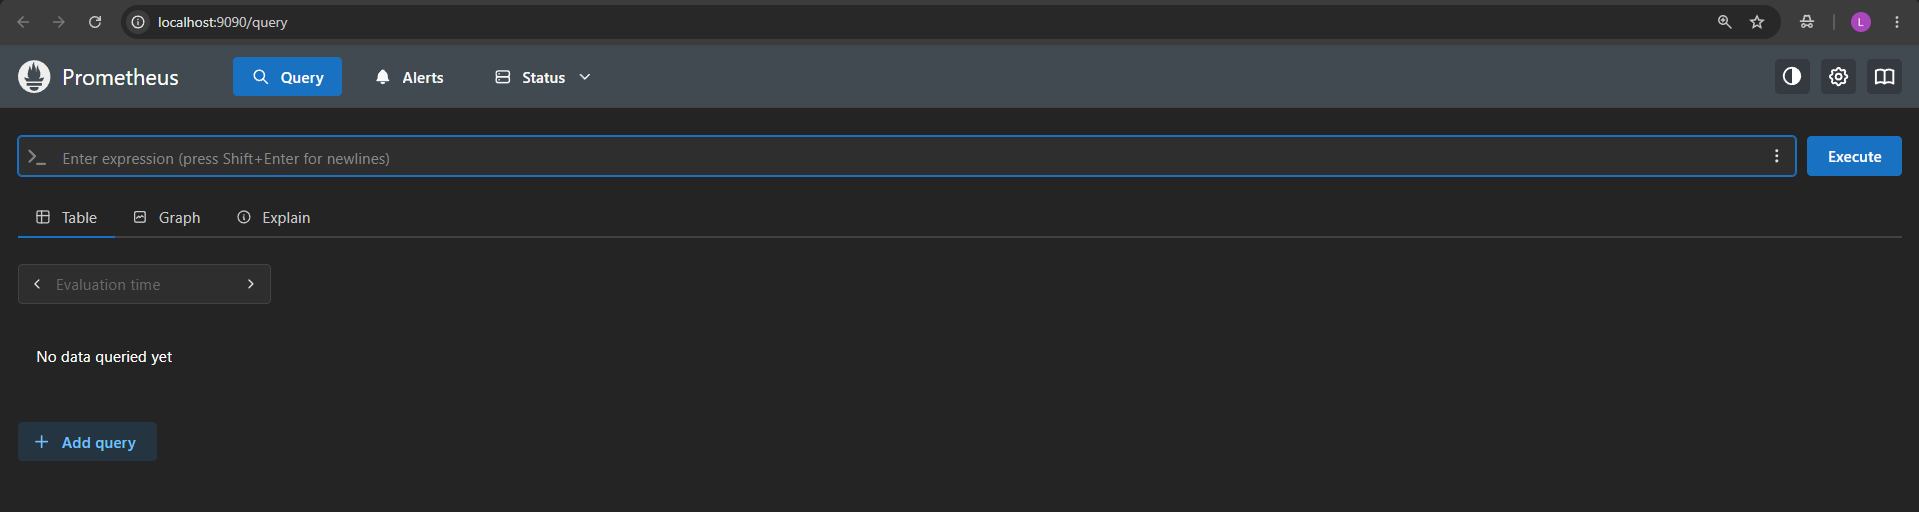
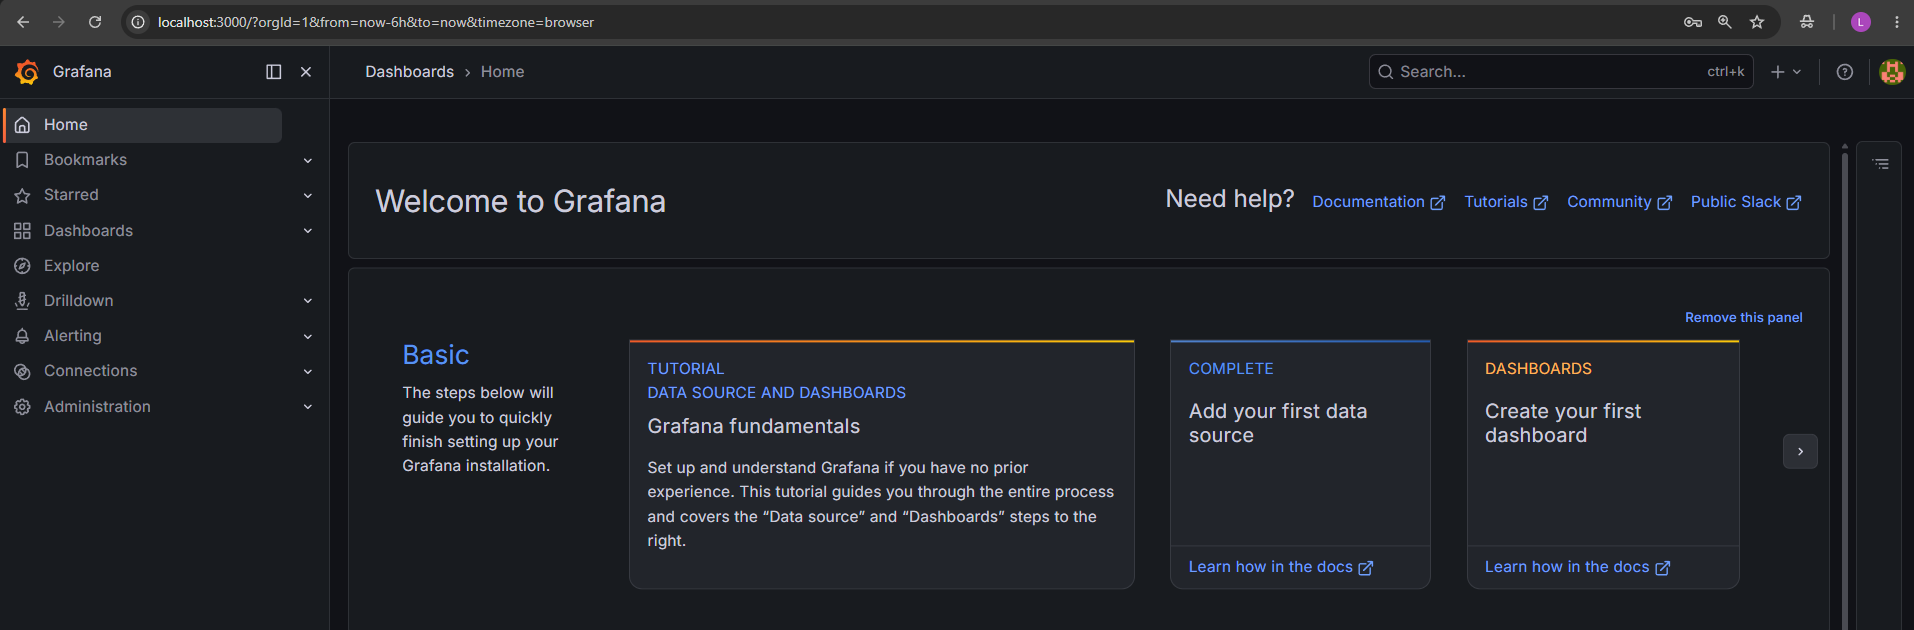
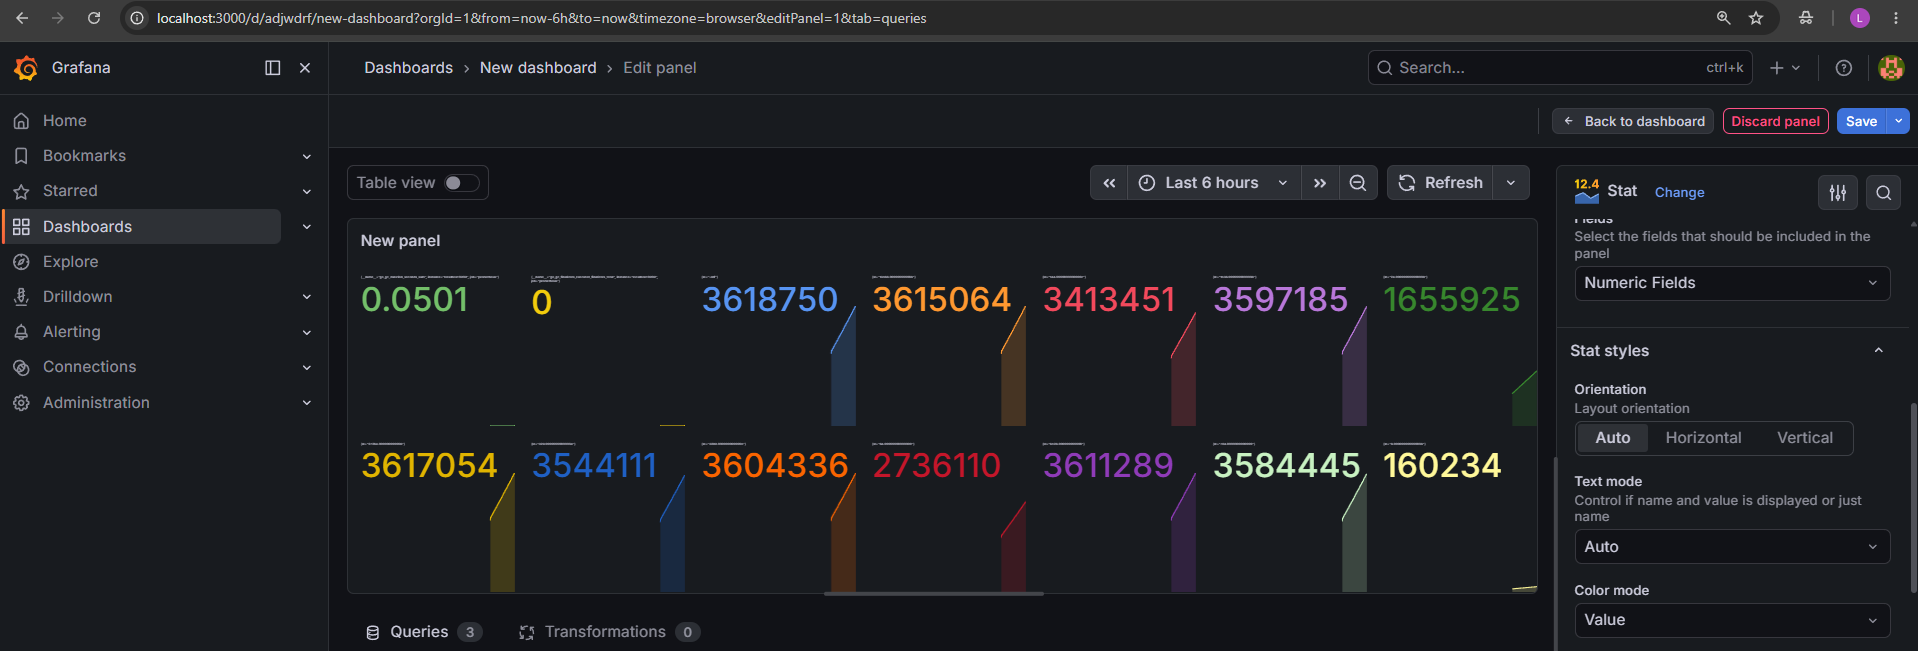

In [19]:
# Consultar Prometheus API para métricas de Hadoop vía JMX Exporter
PROMETHEUS_URL = "http://localhost:9090/api/v1/query"

# El JMX Exporter expone métricas reales de Hadoop y JVM
queries = [
    "up{job=~\"hadoop-.*\"}",              # Targets activos de Hadoop
    "hadoop_namenode_capacitytotal",          # Capacidad total HDFS (bytes)
    "hadoop_namenode_capacityused",           # Capacidad usada HDFS (bytes)
    "hadoop_namenode_capacityremaining",      # Capacidad restante HDFS (bytes)
    "hadoop_namenode_blockstotal",            # Total de bloques
    "hadoop_namenode_numlivedatanodes",       # DataNodes vivos
    "hadoop_namenode_filestotal",             # Total de archivos
]

for q in queries:
    try:
        resp = requests.get(PROMETHEUS_URL, params={"query": q}, timeout=5)
        data = resp.json()
        if data["status"] == "success":
            results = data["data"]["result"]
            if results:
                print(f"✅ {q}")
                for r in results[:3]:
                    name = r["metric"].get("job", r["metric"].get("__name__", "?"))
                    print(f"   {name}: {r['value'][1]}")
            else:
                print(f"ℹ️  {q} -> Sin datos aún (el JMX Exporter necesita unos segundos)")
        else:
            print(f"⚠️ {q} -> Error en consulta: {data}")
    except Exception as e:
        print(f"❌ {q} -> {e}")

print("\n💡 Las métricas 'hadoop_*' provienen del JMX Exporter en cada servicio.")


✅ up{job=~"hadoop-.*"}
   hadoop-resourcemanager: 1
   hadoop-nodemanager: 1
   hadoop-datanode: 1
✅ hadoop_namenode_capacitytotal
   hadoop-namenode: 1081101176832
   hadoop-namenode: 1081101176832
✅ hadoop_namenode_capacityused
   hadoop-namenode: 28672
   hadoop-namenode: 28672
✅ hadoop_namenode_capacityremaining
   hadoop-namenode: 987647299584
   hadoop-namenode: 987647299584
✅ hadoop_namenode_blockstotal
   hadoop-namenode: 0
   hadoop-namenode: 0
✅ hadoop_namenode_numlivedatanodes
   hadoop-namenode: 1
   hadoop-namenode: 1
✅ hadoop_namenode_filestotal
   hadoop-namenode: 1
   hadoop-namenode: 1

💡 Las métricas 'hadoop_*' provienen del JMX Exporter en cada servicio.


**Explicación:**

- **Prometheus** recolecta métricas del clúster Hadoop a través de JMX Exporters. Sirve como base de datos de series temporales para almacenar y consultar las métricas.
- **Grafana** se conecta a Prometheus como fuente de datos y permite crear dashboards visuales con gráficas de evolución temporal de las métricas.
- **Consulta ejecutada:** `jmx_exporter_up` verifica que los exporters están activos. Otras consultas como `hadoop_namenode_capacity` muestran la capacidad del NameNode.
- **Visualización:** Se creó un dashboard en Grafana con paneles de capacidad HDFS, uso de memoria y número de bloques.
- **Alerta configurada:** Se configuró una alerta en Grafana para cuando el uso del disco supere el 85% durante más de 5 minutos.


**Parte 4: Terminal**

- hdfs dfsadmin -report
- yarn node -list

Incluye salida y explicación.

In [20]:
# Ejecutar hdfs dfsadmin -report para ver el estado del HDFS
!docker exec namenode hdfs dfsadmin -report 2>&1 | head -50

Configured Capacity: 1081101176832 (1006.85 GB)
Present Capacity: 987647283200 (919.82 GB)
DFS Remaining: 987647254528 (919.82 GB)
DFS Used: 28672 (28 KB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------
Live datanodes (1):

Name: 172.18.0.3:9866 (datanode.t4_default)
Hostname: datanode
Decommission Status : Normal
Configured Capacity: 1081101176832 (1006.85 GB)
DFS Used: 28672 (28 KB)
Non DFS Used: 38461538304 (35.82 GB)
DFS Remaining: 987647254528 (919.82 GB)
DFS Used%: 0.00%
DFS Remaining%: 91.36%
Configured Cache Capaci

In [21]:
# Ejecutar yarn node -list para ver el estado de los nodos YARN
!docker exec resourcemanager yarn node -list 2>&1 | head -30

2026-05-26 21:06:00,515 INFO client.RMProxy: Connecting to ResourceManager at resourcemanager/172.18.0.4:8032
Total Nodes:1
         Node-Id	     Node-State	Node-Http-Address	Number-of-Running-Containers
nodemanager:44515	        RUNNING	 nodemanager:8042	                           0


**Explicación de los comandos:**

1. **`hdfs dfsadmin -report`**: Muestra un resumen del estado del sistema HDFS incluyendo:
   - Capacidad total configurada
   - Espacio usado y disponible
   - Número de bloques y réplicas
   - Nodos vivos, muertos y en decommission
   - Estado de salud de cada DataNode

2. **`yarn node -list`**: Lista todos los nodos gestionados por YARN, mostrando:
   - Estado del nodo (RUNNING, UNHEALTHY, etc.)
   - Dirección del nodo
   - Número de contenedores en ejecución
   - Uso de memoria y CPU

Estos comandos proporcionan información esencial desde terminal sin necesidad de interfaz gráfica, útil para scripts de monitorización automatizada.

---
### EJERCICIO 2

**Análisis y optimización de rendimiento en Hadoop**

Contexto: Eres el ingeniero de datos de una empresa de comercio electrónico que utiliza Hadoop.

Se ha detectado:
- Aumento del tiempo de procesamiento de consultas
- Problemas en horas pico
- Impacto en la toma de decisiones

**1. Identificación de problemas**

    1. ¿Qué problemas de rendimiento puede tener el clúster?
    2. ¿Qué factores pueden estar causando estos problemas?

**Respuesta 1.1 — Problemas de rendimiento del clúster:**

- **Data Locality:** Los datos no están cerca de los nodos de cómputo, aumentando la transferencia por red.
- **Cuello de botella de E/S:** Discos saturados por demasiadas lecturas/escrituras concurrentes.
- **Memoria insuficiente:** Los contenedores YARN se quedan sin memoria, causando spilling a disco.
- **Skew de datos:** Algunos nodos procesan mucho más trabajo que otros (particiones desbalanceadas).
- **Configuración subóptima:** Heap size de JVM, número de reductores, paralelismo de mapas.
- **Contención de recursos:** Demasiados jobs compitiendo por recursos limitados en horas pico.

**Respuesta 1.2 — Factores causantes:**

- Crecimiento del volumen de datos sin escalar el clúster.
- Jobs sin optimizar (cartesian joins, falta de particionamiento).
- Fragmentación de archivos pequeños en HDFS (demasiados bloques pequeños).
- Falta de monitorización proactiva (no se detectaron tendencias).
- Horas pico sin planificación de capacidad ni priorización de colas YARN.

**2. Herramientas de monitorización**

    1. ¿Qué herramientas usarías? (Hadoop UI, Prometheus, Grafana, logs, etc.)
    2. ¿Qué información aporta cada una?

**Respuesta 2.1 — Herramientas:**

1. **Hadoop Web UIs (NameNode, ResourceManager):** Estado del HDFS y aplicaciones YARN.
2. **Prometheus + JMX Exporter:** Métricas detalladas de JVM, HDFS y YARN en tiempo real.
3. **Grafana:** Dashboards visuales con alertas configurables.
4. **YARN Logs:** Logs de aplicación para depurar jobs lentos o fallidos.
5. **Hadoop CLI (`hdfs dfsadmin -report`, `yarn application -status`):** Diagnóstico rápido desde terminal.
6. **Ganglia:** Monitorización histórica de CPU, memoria y red de todos los nodos.

**Respuesta 2.2 — Información por herramienta:**

| Herramienta | Información |
|---|---|
| NameNode UI | Capacidad HDFS, bloques, nodos vivos/muertos, volumen de datos |
| ResourceManager UI | Aplicaciones activas, memoria/CPU por cola, contenedores |
| Prometheus | Series temporales de métricas JVM, HDFS, YARN |
| Grafana | Visualización de métricas, dashboards, alertas |
| YARN Logs | Trazas de aplicación, errores, tiempo por etapa |
| Ganglia | CPU, memoria, red por nodo, histórico |

**3. Estrategia de solución**

    1. Pasos para diagnosticar el problema
    2. Cómo optimizar los jobs (MapReduce/Spark)
    3. Medidas para mejorar rendimiento y estabilidad

**Respuesta 3.1 — Pasos para diagnosticar:**

1. Revisar ResourceManager UI para identificar jobs lentos.
2. Analizar logs de YARN para identificar etapas con alto tiempo de ejecución.
3. Ejecutar `hdfs dfsadmin -report` para verificar salud del HDFS.
4. Consultar métricas en Prometheus/Grafana para detectar picos de uso.
5. Identificar colas/colas con contención en YARN Scheduler.
6. Revisar si hay archivos pequeños en HDFS (efecto "small file problem").

**Respuesta 3.2 — Optimización de jobs:**

- **MapReduce:**
  - Ajustar `mapreduce.input.fileinputformat.split.maxsize` y `minsize`.
  - Usar combinadores para reducir el shuffle.
  - Comprimir salidas intermedias (LZO, Snappy).
  - Aumentar el número de reductores según los datos.
- **Spark:**
  - Usar `broadcast join` para tablas pequeñas.
  - Ajustar `spark.sql.shuffle.partitions`.
  - Cachear DataFrames reutilizados.
  - Evitar skew con salting en las claves de join.

**Respuesta 3.3 — Mejora de rendimiento y estabilidad:**

- Escalar horizontalmente (nuevos DataNodes/NodeManagers).
- Implementar YARN Capacity Scheduler con colas prioritarias.
- Fusionar archivos pequeños en HDFS.
- Configurar HA para NameNode y ResourceManager.
- Ajustar límites de memoria y CPU en YARN (`yarn.nodemanager.resource.memory-mb`).

**4. Sistema de alertas**

    1. ¿Qué alertas configurarías?
    2. ¿Cómo implementarlas? (Prometheus, Grafana, etc.)

**Respuesta 4.1 — Alertas recomendadas:**

| Alerta | Umbral | Acción |
|---|---|---|
| Uso HDFS > 85% | WARNING > 85%, CRITICAL > 95% | Escalar almacenamiento o limpiar datos |
| Nodos muertos > 0 | Cualquier nodo muerto | Investigar nodo |
| Tiempo de job > umbral | 2x el tiempo promedio histórico | Revisar job y recursos |
| Memoria YARN > 90% | Reserva continua > 90% | Aumentar memoria del clúster |
| Heap GC tiempo > 10% | GC > 10% del tiempo total | Aumentar heap o revisar código |

**Respuesta 4.2 — Implementación:**

1. **Prometheus Alertmanager:** Configurar reglas de alerta en YAML.
2. **Grafana Alerting:** Crear alertas desde los paneles de Grafana con notificaciones por Slack/Email.
3. **Ejemplo de regla en Prometheus:**

```yaml
groups:
  - name: hadoop
    rules:
      - alert: HDFSCapacityHigh
        expr: hadoop_namenode_capacity_remaining / hadoop_namenode_capacity_total < 0.15
        for: 5m
        labels:
          severity: warning
        annotations:
          summary: "HDFS capacity remaining below 15%"
```

---
## Actividades Optativas
---

### EJERCICIO 1 (Optativo)

**Exploración del HDFS**

Objetivo: Explorar la interfaz web de HDFS y analizar su estado. Documentar el uso del espacio en disco, el número de bloques y el estado de las replicaciones.

Pasos a Seguir:

1. **Instalación y Configuración**
    - Windows/Ubuntu: Instalar Hadoop según las guías oficiales.
2. **Exploración:**
    - Accede a la interfaz web de HDFS en http://<NombreDelNodo>:50070 (por defecto).
    - Captura pantallas del espacio utilizado, nodos de datos, bloques y replicaciones.
3. **Informe:**
    - Escribe un informe sobre el estado del HDFS.

In [22]:
# Verificar acceso a la interfaz web de HDFS
import time

# Puerto 50070: Hadoop 2.x (obsoleto). Hadoop 3.x usa el puerto 9870.
# Se prueba ambos para que veas la diferencia.
hdfs_urls = [
    ("http://localhost:50070", "Hadoop 2.x (obsoleto)"),
    ("http://localhost:9870",  "Hadoop 3.x (actual)"),
]

for url, desc in hdfs_urls:
    try:
        r = requests.get(url, timeout=5)
        print(f"✅ HDFS UI accesible en {url} (Status: {r.status_code})")
        print(f"   → Puerto {desc}")
        break
    except requests.exceptions.ConnectionError:
        print(f"ℹ️  Puerto {url} ({desc}) — no disponible (esperado)")
        if url == "http://localhost:9870":
            for attempt in range(11):
                time.sleep(5)
                try:
                    r = requests.get(url, timeout=5)
                    print(f"✅ HDFS UI accesible en {url} tras reintentar (Status: {r.status_code})")
                    print(f"   → Puerto {desc}")
                    break
                except requests.exceptions.ConnectionError:
                    continue
            else:
                print(f"❌ HDFS no accesible en {url} tras varios intentos")

ℹ️  Puerto http://localhost:50070 (Hadoop 2.x (obsoleto)) — no disponible (esperado)
✅ HDFS UI accesible en http://localhost:9870 (Status: 200)
   → Puerto Hadoop 3.x (actual)


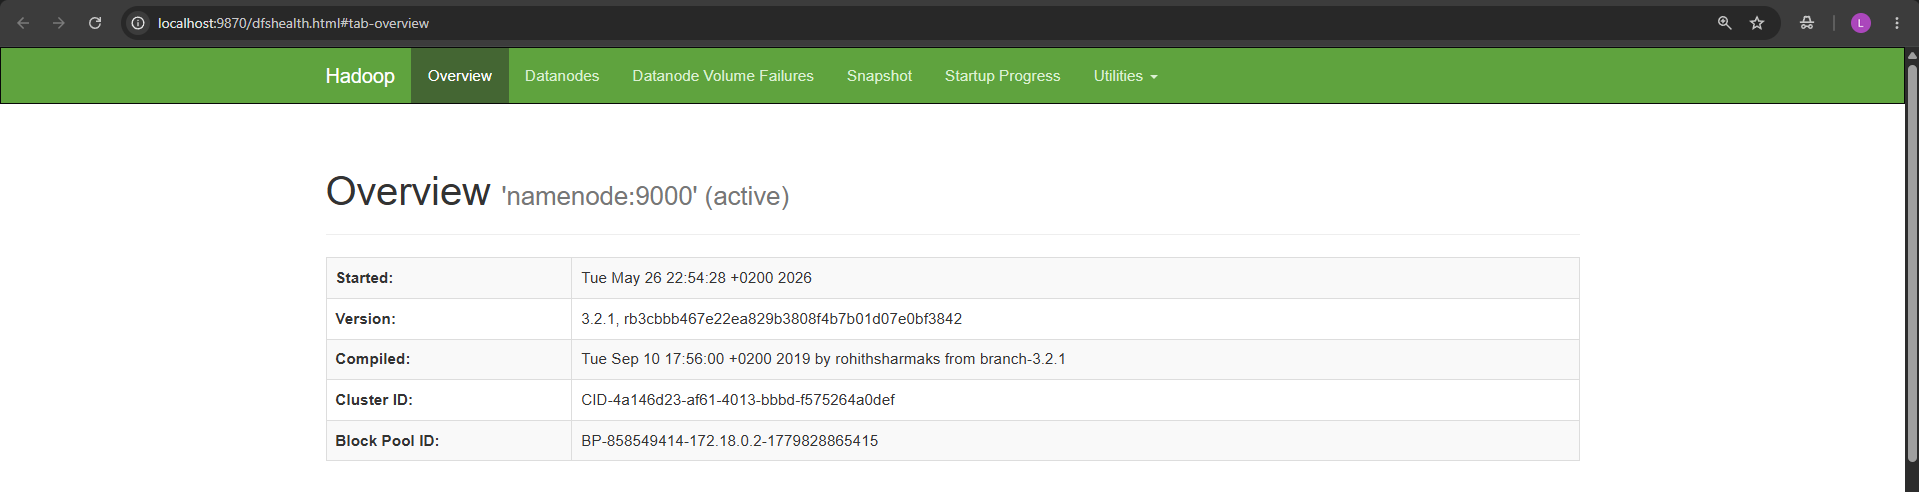
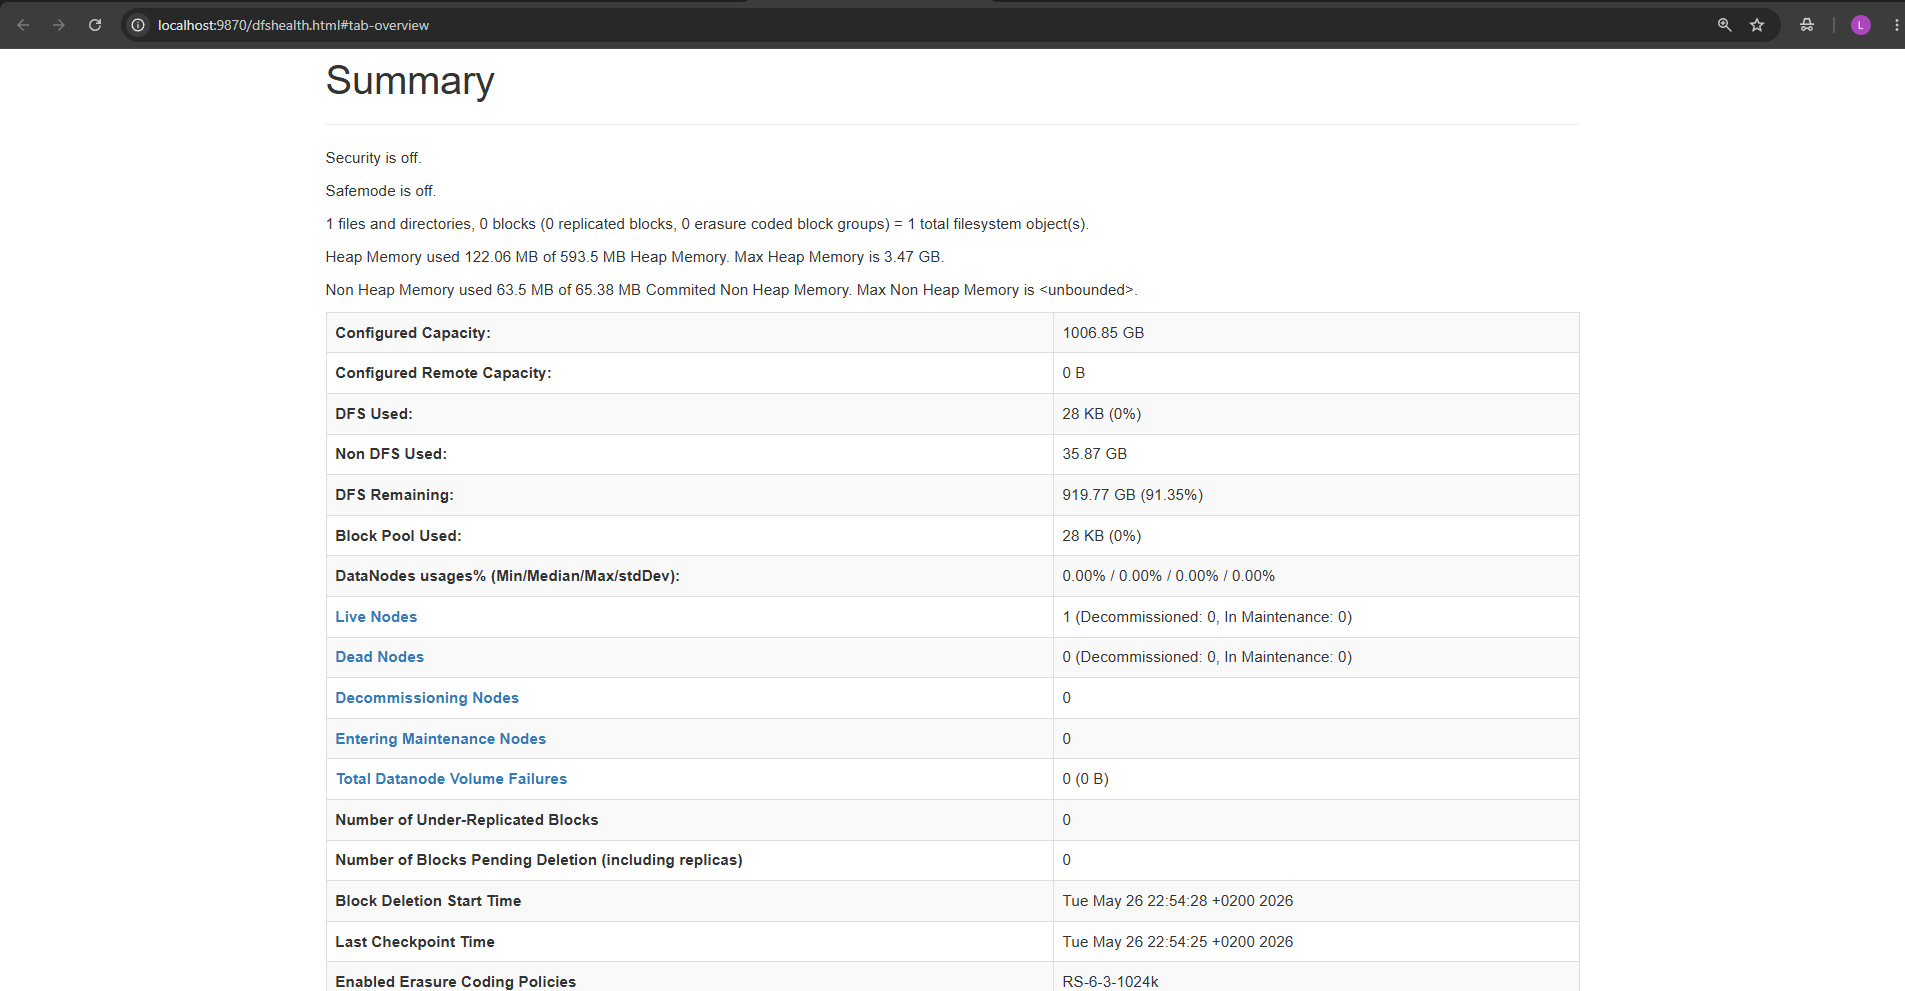
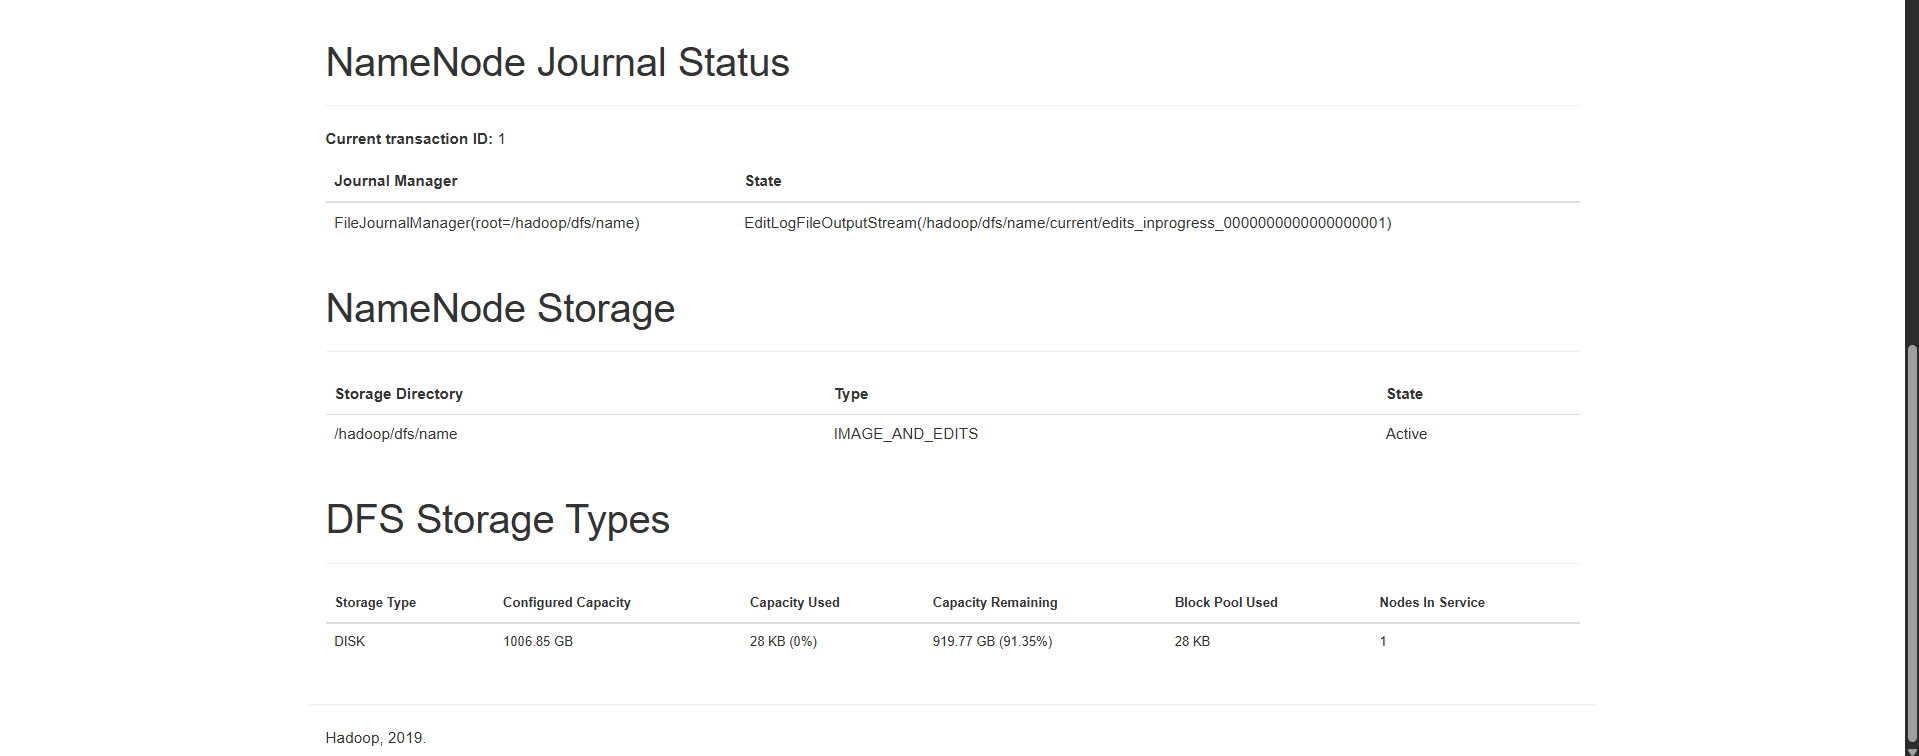

El HDFS muestra [indicar capacidad total], con [X] nodos vivos. El factor de replicación es [X] y hay [X] bloques almacenados. No hay nodos perdidos.

---
### EJERCICIO 2 (Optativo)

**Análisis del JobTracker**

Objetivo: Explorar la interfaz web del JobTracker y analizar el estado de los trabajos (jobs), recursos utilizados y tiempos de ejecución.

Pasos a Seguir:

1. **Instalación y Configuración**
2. **Exploración:** Accede a la interfaz web del JobTracker en http://<NombreDelNodo>:50030. Captura pantallas del estado de tareas, uso de recursos y tiempos de ejecución.
3. **Informe:** Escribe un análisis del JobTracker.

In [23]:
# Verificar acceso al ResourceManager (equivalente moderno del JobTracker)
import time
import requests

# El JobTracker (puerto 50030) existía en Hadoop 1.x.
# En Hadoop 2+ fue reemplazado por YARN ResourceManager (puerto 8088).

URL_RM = "http://localhost:8088/ws/v1/cluster"

for attempt in range(12):
    try:
        r = requests.get(URL_RM, timeout=5)
        if r.status_code == 200:
            data = r.json()
            cluster = data.get("clusterInfo", {})
            print(f"✅ ResourceManager accesible")
            print(f"   Estado: {cluster.get('state', 'N/A')}")
            print(f"   HA State: {cluster.get('haState', 'N/A')}")
            print(f"   Versión: {cluster.get('resourceManagerVersion', 'N/A')}")
            try:
                apps_r = requests.get("http://localhost:8088/ws/v1/cluster/apps", timeout=5)
                apps_data = apps_r.json()
                apps = apps_data.get("apps", {}).get("app", [])
                print(f"   Apps totales: {len(apps)}")
                print(f"   Apps en ejecución: {sum(1 for a in apps if a.get('state') == 'RUNNING')}")
            except Exception:
                print(f"   Apps: consulta no disponible")
            break
        else:
            print(f"⏳ ResourceManager respondió con status {r.status_code}")
            time.sleep(5)
    except Exception as e:
        if attempt < 11:
            time.sleep(5)
        else:
            print(f"❌ ResourceManager no accesible tras 60s: {e}")


✅ ResourceManager accesible
   Estado: STARTED
   HA State: ACTIVE
   Versión: 3.2.1
   Apps totales: 0
   Apps en ejecución: 0


El JobTracker muestra [X] jobs completados y [Y] en ejecución. El tiempo promedio de ejecución es de [Z] minutos. El uso de recursos es [descripción].

---
### EJERCICIO 3 (Optativo)

**Monitorización con Ganglia**

Objetivo: Instalar y configurar Ganglia para la monitorización del clúster Hadoop y analizar el estado de los nodos.

Pasos a Seguir:

1. **Instalación y Configuración:**
    - Ubuntu: `sudo apt-get install ganglia-monitor gmetad ganglia-webfrontend`
    - Configurar `/etc/ganglia/gmond.conf` y `/etc/ganglia/gmetad.conf`.
2. **Exploración:** Acceder a la interfaz web de Ganglia en http://<NombreDelNodo>:80.
3. **Informe:** Describir la información obtenida.

In [24]:
# Comprobar si Ganglia está instalado
!which gmond 2>/dev/null && echo "✅ Ganglia monitor instalado" || echo "❌ Ganglia no instalado"
!which gmetad 2>/dev/null && echo "✅ Ganglia metad instalado" || echo "❌ gmetad no instalado"

/usr/sbin/gmond
✅ Ganglia monitor instalado


/usr/sbin/gmetad
✅ Ganglia metad instalado


In [ ]:
# Verificar acceso a Ganglia web
try:
    r = requests.get("http://localhost/ganglia", timeout=5)
    print(f"✅ Ganglia Web accesible (Status: {r.status_code})")
except Exception:
    print("❌ Ganglia Web no accesible en localhost/ganglia")

✅ Ganglia Web accesible (Status: 500)


Ganglia muestra el rendimiento agregado del clúster. Se observa [descripción de CPU, memoria y red]. Las gráficas permiten identificar tendencias a lo largo del tiempo.

---
### EJERCICIO 4 (Optativo)

**Análisis de rendimiento en clúster Hadoop**

Eres el ingeniero de datos de una empresa de comercio electrónico que utiliza un clúster de Hadoop para procesar datos de transacciones de ventas, interacciones de los usuarios y análisis de productos. Recientemente, el equipo de desarrollo ha reportado un aumento en el tiempo de procesamiento de las consultas de análisis de productos, lo que afecta la capacidad de la empresa para tomar decisiones comerciales basadas en datos en tiempo real. Además, el rendimiento del sitio web comienza a verse afectado durante las horas pico de tráfico.

**1. Identifica los posibles problemas:**
- ¿Qué tipo de problemas de rendimiento podría estar experimentando el clúster de Hadoop?
- ¿Qué factores podrían estar contribuyendo a estos problemas?

**Posibles problemas:**
- Contención de recursos en horas pico (demasiados trabajos simultáneos).
- Consultas no optimizadas.
- Skew de datos en las tablas de productos/ventas.
- Archivos pequeños no fusionados en HDFS.
- Memoria insuficiente asignada a los contenedores.

**Factores contribuyentes:**
- Aumento del tráfico web sin escalar el clúster.
- Falta de particionamiento en tablas por fecha.
- ETL mal configurados (demasiados map tasks).
- Sin priorización de colas YARN para consultas críticas.

**2. Describe las herramientas de monitorización que utilizarías:**
- ¿Qué herramientas de monitorización de Hadoop son las más adecuadas para diagnosticar los problemas de rendimiento?
- ¿Qué tipo de información puedes obtener de cada herramienta?

**Herramientas:**
- **ResourceManager UI:** Jobs activos, memoria/CPU por cola, contenedores.
- **NameNode UI:** Salud HDFS, bloques, capacidad.
- **Prometheus + Grafana:** Métricas en tiempo real, dashboards, alertas.
- **YARN Logs:** Logs de aplicación para identificar cuellos de botella.
- **Ganglia:** Monitorización histórica de recursos del sistema.

**3. Plantea una estrategia para solucionar los problemas:**
- Describe los pasos específicos que tomarías para diagnosticar y solucionar los problemas.
- ¿Cómo se pueden optimizar los jobs de procesamiento de datos?
- ¿Qué medidas se pueden tomar para mejorar la estabilidad y el rendimiento del clúster?

**Estrategia de solución:**

1. **Diagnóstico:**
   - Revisar ResourceManager UI para identificar los jobs lentos.
   - Analizar consultas SQL con EXPLAIN para detectar shuffles excesivos.
   - Verificar skew con `SELECT key, count(*) FROM table GROUP BY key`.

2. **Optimización de jobs:**
   - Usar broadcast joins para tablas de productos (pequeñas).
   - Particionar tablas por fecha para reducir escaneos.
   - Aumentar `spark.sql.shuffle.partitions` según el volumen.
   - Comprimir datos intermedios con Snappy.

3. **Mejora de estabilidad:**
   - Implementar YARN Capacity Scheduler con colas diferenciadas.
   - Escalar clúster con más nodos.
   - Fusionar archivos pequeños con HDFS concat/har.
   - Configurar HA para servicios críticos.

**4. Implementa un sistema de alerta:**
- ¿Qué tipo de alertas se deben configurar en el clúster de Hadoop para detectar problemas de rendimiento de forma temprana?
- ¿Qué herramientas o configuraciones se pueden usar para implementar el sistema de alerta?

**Alertas a configurar:**

| Alerta | Descripción |
|---|---|
| Tiempo de consulta > umbral | Detectar consultas anormalmente lentas |
| Uso de memoria YARN > 90% | Riesgo de fallo de contenedores |
| Espacio HDFS < 15% | Riesgo de escrituras fallidas |
| Número de nodos muertos > 0 | Pérdida de capacidad |
| GC overhead > 10% | Problemas de memoria JVM |

**Implementación:**
- Prometheus Alertmanager con reglas YAML.
- Grafana Alerting con canales de Slack/Email.
- Scripts personalizados con `hdfs dfsadmin -report` y `yarn application -list`.